# 20newsgroups
The 20 newsgroups dataset comprises around 18000 newsgroups posts on 20 topics split in two subsets: one for training (or development) and the other one for testing (or for performance evaluation). The split between the train and test set is based upon a messages posted before and after a specific date.



<img src="https://frenzy86.s3.eu-west-2.amazonaws.com/python/nlp/20newsgroup.png" width="1200">

This dataset is a collection newsgroup documents. The 20 newsgroups collection has become a popular data set for experiments in text applications of machine learning techniques, such as text classification and text clustering.

Each newsgroup file in the bundle represents a single newsgroup
Each message in a file is the text of some newsgroup document that was posted to that newsgroup.
This is a list of the 20 newsgroups:

- comp.graphics
- comp.os.ms-windows.misc
- comp.sys.ibm.pc.hardware
- comp.sys.mac.hardware
- comp.windows.x rec.autos
- rec.motorcycles
- rec.sport.baseball
- rec.sport.hockey sci.crypt
- sci.electronics
- sci.med
- sci.space
- misc.forsale talk.politics.misc
- talk.politics.guns
- talk.politics.mideast talk.religion.misc
- alt.atheism
- soc.religion.christian

In [1]:
from sklearn.datasets import fetch_20newsgroups

In [2]:
data = fetch_20newsgroups(
                        subset='all',
                        remove=(),           # mantiene headers, footers e quotes
                        shuffle=True,
                        random_state=667
                        )

X = data.data            # lista di stringhe (i testi)
y = data.target          # array di interi (label)
target_names = data.target_names

print(f"Documenti totali: {len(X)}")
print(f"Numero categorie: {len(target_names)}")
print(f"Categorie: {target_names}")

Documenti totali: 18846
Numero categorie: 20
Categorie: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


## BOW + TF-IDF

In [3]:
##STEP 2: Vettorizzazione
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=1500, min_df=5, max_df=0.7,stop_words='english')
#vectorizer = CountVectorizer(stop_words='english')
X_vect = vectorizer.fit_transform(X).toarray()
X_vect

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [4]:
X_vect.shape

(18846, 1500)

In [5]:
##STEP 3: TF-IDF
from sklearn.feature_extraction.text import TfidfTransformer

tfidfconverter = TfidfTransformer()
X_tfidf = tfidfconverter.fit_transform(X_vect).toarray()
X_tfidf

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.11992023, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [6]:
##STEP 4: Split Training and Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y,
                                                    test_size=0.3,
                                                    random_state=667
                                                    )

In [7]:
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score

classifier = MultinomialNB(alpha=.01)
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]

print(classification_report(y_test,y_pred))
print(f1_score(y_test, y_pred, average='macro'))

              precision    recall  f1-score   support

           0       0.81      0.77      0.79       264
           1       0.63      0.70      0.66       291
           2       0.70      0.75      0.72       303
           3       0.66      0.69      0.67       265
           4       0.78      0.69      0.73       295
           5       0.79      0.81      0.80       296
           6       0.79      0.84      0.81       285
           7       0.77      0.81      0.79       303
           8       0.81      0.84      0.83       302
           9       0.89      0.84      0.87       295
          10       0.88      0.91      0.90       313
          11       0.93      0.87      0.90       317
          12       0.71      0.66      0.68       296
          13       0.88      0.85      0.87       289
          14       0.84      0.85      0.84       274
          15       0.81      0.90      0.85       307
          16       0.76      0.92      0.83       272
          17       0.89    

Text(145.72222222222223, 0.5, 'Actual')

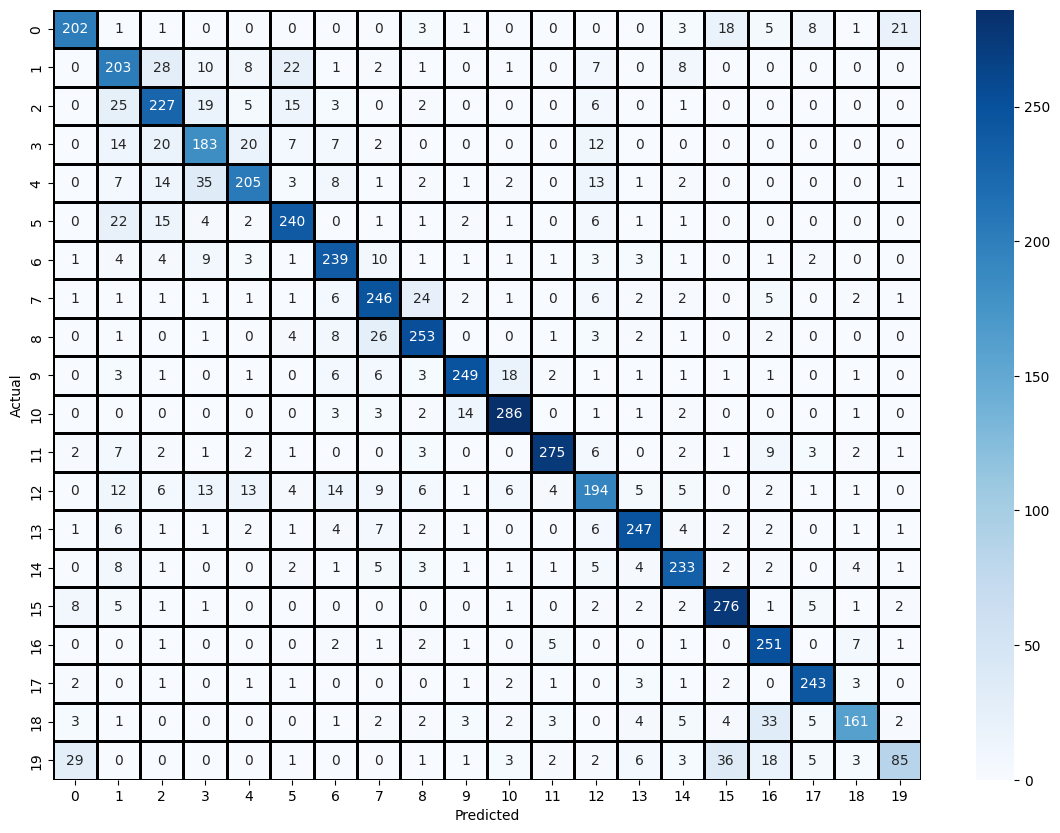

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (14,10))
sns.heatmap(cm,cmap= "Blues",
            linecolor = 'black',
            linewidth = 1,
            annot = True,
            fmt='')

plt.xlabel("Predicted")
plt.ylabel("Actual")

In [9]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=50,max_depth=5)
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]

print(classification_report(y_test,y_pred))
print(f1_score(y_test, y_pred, average='macro'))

              precision    recall  f1-score   support

           0       0.90      0.07      0.13       264
           1       0.67      0.44      0.53       291
           2       0.67      0.62      0.64       303
           3       0.50      0.51      0.50       265
           4       0.76      0.51      0.61       295
           5       0.92      0.36      0.52       296
           6       0.76      0.73      0.75       285
           7       0.76      0.62      0.68       303
           8       0.86      0.77      0.81       302
           9       0.72      0.60      0.66       295
          10       0.77      0.79      0.78       313
          11       0.77      0.87      0.82       317
          12       0.86      0.04      0.08       296
          13       0.18      0.87      0.30       289
          14       0.65      0.70      0.67       274
          15       0.49      0.87      0.63       307
          16       0.70      0.79      0.74       272
          17       0.82    

Text(145.72222222222223, 0.5, 'Actual')

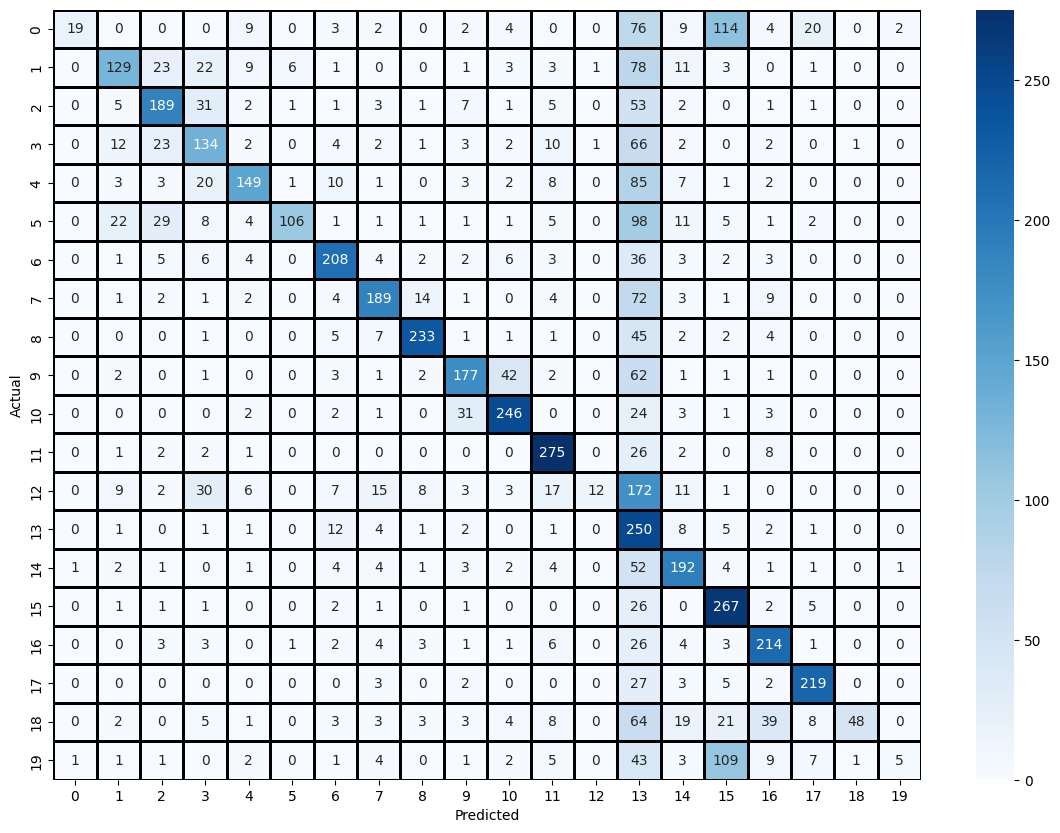

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (14,10))
sns.heatmap(cm,cmap= "Blues",
            linecolor = 'black',
            linewidth = 1,
            annot = True,
            fmt='')

plt.xlabel("Predicted")
plt.ylabel("Actual")

## Pipeline

In [12]:
##STEP 4: Split Training and Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, ############## QUI IL DATASET NON CON BAGOFWORDS
                                                    test_size=0.3,
                                                    random_state=667
                                                    )

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

bow = CountVectorizer(stop_words='english')
tfidf = TfidfTransformer()
classifier = MultinomialNB(alpha=.01)

pipe = Pipeline([('bow', bow),
                 ('tfidf', tfidf),
                 ('estimator', classifier),
                ])

pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)
f1_score(y_test, y_pred, average='macro')

0.9108730377625147

Text(95.72222222222221, 0.5, 'Actual')

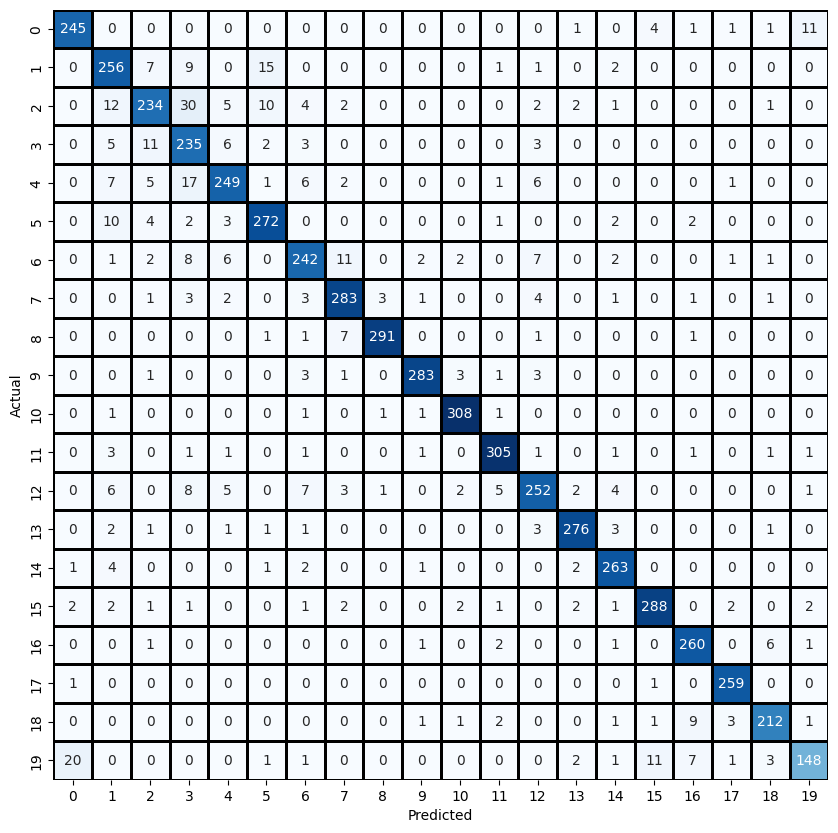

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (10,10))
sns.heatmap(cm,cmap= "Blues",
            linecolor = 'black',
            linewidth = 1,
            annot = True,
            fmt='',
            cbar=False,
            )

plt.xlabel("Predicted")
plt.ylabel("Actual")